# Holiday Effect on Sales in Vietnam

This notebook analyzes the impact of major Vietnamese holidays on sales using the 2025 transaction data. All data processing is performed with Polars. The analysis follows these steps:

1. Import required libraries
2. Load and inspect transaction data
3. Define Vietnamese holidays and analysis windows
4. Aggregate daily sales totals
5. Compute holiday lift and baseline
6. Statistical testing: holiday vs baseline
7. Visualize daily sales and holiday windows
8. Visualize holiday lift by holiday
9. Visualize weekday vs holiday-window sales
10. Decision rule: evaluate holiday effect


In [5]:
# 1. Import Required Libraries and Set Up Polars
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import datetime

pl.Config.set_tbl_rows(10)
pl.Config.set_tbl_cols(20)


polars.config.Config

## 2. Load and Inspect Transaction Data

Load the 2025 transaction data and inspect the schema and a sample of rows to confirm data types, especially for 'updated_date', 'quantity', 'customer_id', and 'item_id'.

In [6]:
# Load transaction data
TRANSACTION_PATH = '../transaction_full_2025.parquet'
df = pl.read_parquet(TRANSACTION_PATH)
# Show head and schema for type reference
df_head = df.head(10)
df_schema = df.schema
print(df_head)
print(df_schema)

shape: (10, 8)
┌───────────┬────────────┬────────────┬────────────┬──────────┬────────────┬───────────┬───────────┐
│ bill_id   ┆ customer_i ┆ item_id    ┆ price      ┆ quantity ┆ event_type ┆ updated_d ┆ location_ │
│ ---       ┆ d          ┆ ---        ┆ ---        ┆ ---      ┆ ---        ┆ ate       ┆ name      │
│ i32       ┆ ---        ┆ str        ┆ decimal[38 ┆ i32      ┆ str        ┆ ---       ┆ ---       │
│           ┆ i32        ┆            ┆ ,4]        ┆          ┆            ┆ datetime[ ┆ str       │
│           ┆            ┆            ┆            ┆          ┆            ┆ μs]       ┆           │
╞═══════════╪════════════╪════════════╪════════════╪══════════╪════════════╪═══════════╪═══════════╡
│ 137262467 ┆ 6291331    ┆ 6767000000 ┆ 285000.000 ┆ 1        ┆ Purchase   ┆ 2025-04-1 ┆ QNG - 255 │
│           ┆            ┆ 002        ┆ 0          ┆          ┆            ┆ 2 12:52:4 ┆ Quốc Lộ   │
│           ┆            ┆            ┆            ┆          ┆            ┆

## 3. Define Vietnamese Holidays and Analysis Windows

List the major Vietnamese holidays for 2025 and define pre-holiday, holiday, and post-holiday windows for each. Also, define a baseline window from nearby non-holiday days.

### Column Types (from parquet_analysis_report)
- updated_date: datetime[μs]
- quantity: Int64
- customer_id: Int64 or Utf8 (check schema)
- item_id: Int64 or Utf8 (check schema)

See parquet_analysis_report for full schema details.

In [7]:
# Define major Vietnamese holidays for 2025
holidays = [
    {"name": "Tet Nguyen Dan", "start": "2025-01-28", "end": "2025-02-03"},
    {"name": "Hung Kings Commemoration Day", "start": "2025-04-09", "end": "2025-04-09"},
    {"name": "Reunification Day", "start": "2025-04-30", "end": "2025-04-30"},
    {"name": "International Labor Day", "start": "2025-05-01", "end": "2025-05-01"},
    {"name": "National Day", "start": "2025-09-02", "end": "2025-09-02"},
    {"name": "Mid-Autumn Festival", "start": "2025-10-06", "end": "2025-10-06"},
]

# Define analysis windows for each holiday
window_days = {"pre": 7, "post": 7}
holiday_windows = []
for h in holidays:
    start = datetime.date.fromisoformat(h["start"])
    end = datetime.date.fromisoformat(h["end"])
    pre_start = start - datetime.timedelta(days=window_days["pre"])
    pre_end = start - datetime.timedelta(days=1)
    post_start = end + datetime.timedelta(days=1)
    post_end = end + datetime.timedelta(days=window_days["post"])
    holiday_windows.append({
        "name": h["name"],
        "pre": (pre_start, pre_end),
        "holiday": (start, end),
        "post": (post_start, post_end)
    })
holiday_windows

[{'name': 'Tet Nguyen Dan',
  'pre': (datetime.date(2025, 1, 21), datetime.date(2025, 1, 27)),
  'holiday': (datetime.date(2025, 1, 28), datetime.date(2025, 2, 3)),
  'post': (datetime.date(2025, 2, 4), datetime.date(2025, 2, 10))},
 {'name': 'Hung Kings Commemoration Day',
  'pre': (datetime.date(2025, 4, 2), datetime.date(2025, 4, 8)),
  'holiday': (datetime.date(2025, 4, 9), datetime.date(2025, 4, 9)),
  'post': (datetime.date(2025, 4, 10), datetime.date(2025, 4, 16))},
 {'name': 'Reunification Day',
  'pre': (datetime.date(2025, 4, 23), datetime.date(2025, 4, 29)),
  'holiday': (datetime.date(2025, 4, 30), datetime.date(2025, 4, 30)),
  'post': (datetime.date(2025, 5, 1), datetime.date(2025, 5, 7))},
 {'name': 'International Labor Day',
  'pre': (datetime.date(2025, 4, 24), datetime.date(2025, 4, 30)),
  'holiday': (datetime.date(2025, 5, 1), datetime.date(2025, 5, 1)),
  'post': (datetime.date(2025, 5, 2), datetime.date(2025, 5, 8))},
 {'name': 'National Day',
  'pre': (datetime.d

## 4. Aggregate Daily Sales Totals

Transform transaction data to daily sales totals by summing 'quantity' per day. Ensure 'updated_date' is already datetime type and aggregate correctly.

In [13]:
# 'updated_date' is already datetime, so just extract date part
daily_sales = (
    df.with_columns([
        pl.col("updated_date").dt.date().alias("date")
    ])
    .group_by("date")
    .agg(pl.col("quantity").sum().alias("daily_quantity"))
    .sort("date")
)
daily_sales.head(10)

date,daily_quantity
date,i32
2025-01-01,185001
2025-01-02,159855
2025-01-03,145932
2025-01-04,152668
2025-01-05,165224
2025-01-06,161048
2025-01-07,151772
2025-01-08,148278
2025-01-09,147081


## 4. Aggregate Daily Sales Totals

Transform transaction data to daily sales totals by summing 'quantity' per day. Ensure 'updated_date' is converted to date type and aggregated correctly.

## 5. Compute Holiday Lift and Baseline

For each holiday and its windows, calculate total and average daily sales. Compute holiday lift using the formula: $\text{lift} = \frac{S_{holiday} - S_{baseline}}{S_{baseline}}$.

In [15]:
# Compute holiday lift and baseline for each holiday
results = []
for hw in holiday_windows:
    name = hw["name"]
    # Extract sales for each window
    pre = daily_sales.filter((pl.col("date") >= pl.lit(hw["pre"][0])) & (pl.col("date") <= pl.lit(hw["pre"][1])))
    holiday = daily_sales.filter((pl.col("date") >= pl.lit(hw["holiday"][0])) & (pl.col("date") <= pl.lit(hw["holiday"][1])))
    post = daily_sales.filter((pl.col("date") >= pl.lit(hw["post"][0])) & (pl.col("date") <= pl.lit(hw["post"][1])))
    # Baseline: 14 days before pre-holiday
    baseline_start = hw["pre"][0] - datetime.timedelta(days=14)
    baseline_end = hw["pre"][0] - datetime.timedelta(days=1)
    baseline = daily_sales.filter((pl.col("date") >= pl.lit(baseline_start)) & (pl.col("date") <= pl.lit(baseline_end)))
    # Compute means
    S_holiday = holiday["daily_quantity"].mean()
    S_baseline = baseline["daily_quantity"].mean()
    lift = (S_holiday - S_baseline) / S_baseline if S_baseline else None
    results.append({
        "holiday": name,
        "S_holiday": S_holiday,
        "S_baseline": S_baseline,
        "lift": lift,
        "n_holiday": holiday.height,
        "n_baseline": baseline.height
    })
import pandas as pd
results_df = pd.DataFrame(results)
results_df

,holiday,S_holiday,S_baseline,lift,n_holiday,n_baseline
0,Tet Nguyen Dan,111975.0,166357.285714,-0.326901,7,14
1,Hung Kings Commemoration Day,148225.0,149658.000000,-0.009575,1,14
2,Reunification Day,176273.0,159875.857143,0.102562,1,14
3,International Labor Day,188544.0,159361.357143,0.183122,1,14
4,National Day,208031.0,171958.500000,0.209774,1,14
5,Mid-Autumn Festival,181066.0,185792.428571,-0.025439,1,14


## 6. Statistical Testing: Holiday vs Baseline

For each holiday, compare daily sales in holiday windows to baseline using a two-sample t-test if distributions are normal, or Mann-Whitney U test if skewed. If sales counts are very discrete, fit a Poisson or negative binomial regression with holiday-window indicators.

In [16]:
# Statistical testing for each holiday
stat_results = []
for hw in holiday_windows:
    name = hw["name"]
    # Extract sales for holiday and baseline
    holiday = daily_sales.filter((pl.col("date") >= pl.lit(hw["holiday"][0])) & (pl.col("date") <= pl.lit(hw["holiday"][1])))
    baseline_start = hw["pre"][0] - datetime.timedelta(days=14)
    baseline_end = hw["pre"][0] - datetime.timedelta(days=1)
    baseline = daily_sales.filter((pl.col("date") >= pl.lit(baseline_start)) & (pl.col("date") <= pl.lit(baseline_end)))
    h_sales = holiday["daily_quantity"].to_numpy()
    b_sales = baseline["daily_quantity"].to_numpy()
    # Normality check
    h_norm = stats.shapiro(h_sales)[1] > 0.05 if len(h_sales) >= 3 else False
    b_norm = stats.shapiro(b_sales)[1] > 0.05 if len(b_sales) >= 3 else False
    if h_norm and b_norm:
        t_stat, p_val = stats.ttest_ind(h_sales, b_sales, equal_var=False)
        test = "t-test"
    else:
        t_stat, p_val = stats.mannwhitneyu(h_sales, b_sales, alternative="two-sided")
        test = "Mann-Whitney U"
    stat_results.append({
        "holiday": name,
        "test": test,
        "statistic": t_stat,
        "p_value": p_val
    })
stat_results_df = pd.DataFrame(stat_results)
stat_results_df

,holiday,test,statistic,p_value
0,Tet Nguyen Dan,t-test,-1.707459,0.136962
1,Hung Kings Commemoration Day,Mann-Whitney U,6.000000,0.933333
2,Reunification Day,Mann-Whitney U,12.000000,0.400000
3,International Labor Day,Mann-Whitney U,14.000000,0.133333
4,National Day,Mann-Whitney U,14.000000,0.133333
5,Mid-Autumn Festival,Mann-Whitney U,7.000000,1.000000


## 7. Visualize Daily Sales and Holiday Windows

Plot a line chart of daily sales with shaded regions for pre-holiday, holiday, and post-holiday windows for each holiday.

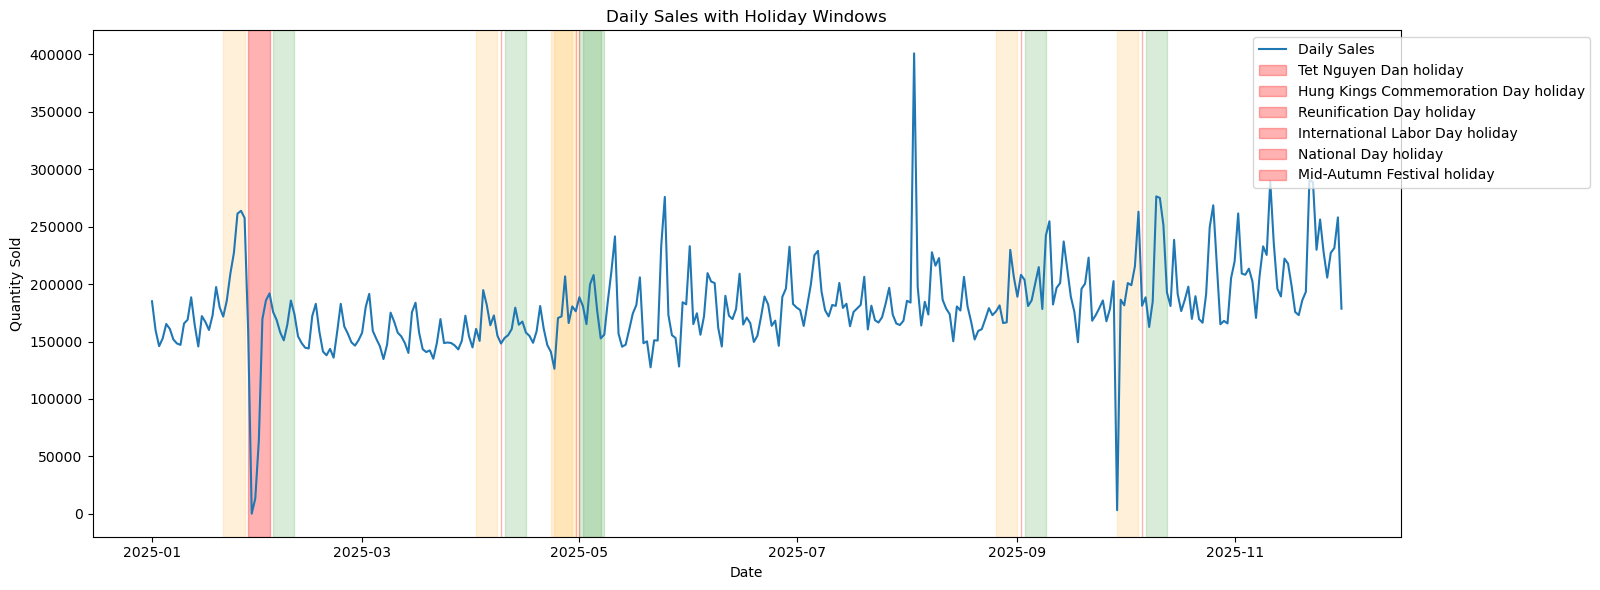

In [17]:
# Plot daily sales with holiday windows
plt.figure(figsize=(16, 6))
plt.plot(daily_sales['date'].to_numpy(), daily_sales['daily_quantity'].to_numpy(), label='Daily Sales')
for hw in holiday_windows:
    for window, color, alpha in zip(['pre', 'holiday', 'post'], ['orange', 'red', 'green'], [0.15, 0.3, 0.15]):
        w = hw[window]
        plt.axvspan(w[0], w[1], color=color, alpha=alpha, label=f"{hw['name']} {window}" if window == 'holiday' else None)
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.title('Daily Sales with Holiday Windows')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

## 8. Visualize Holiday Lift by Holiday

Create a bar chart showing the computed holiday lift for each holiday.

C:\Users\Quoc Kien\AppData\Local\Temp\ipykernel_27196\2163211621.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='holiday', y='lift', data=results_df, palette='viridis')


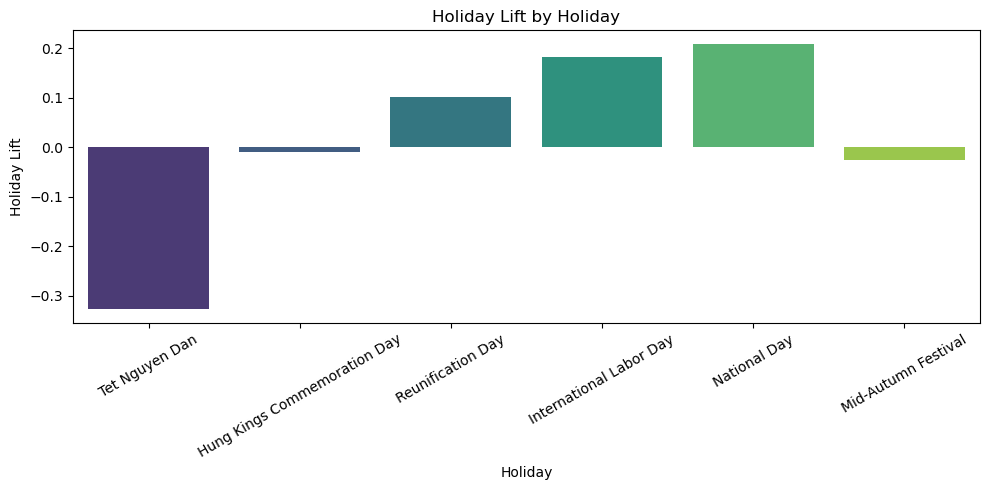

In [18]:
# Bar chart of holiday lift
plt.figure(figsize=(10, 5))
sns.barplot(x='holiday', y='lift', data=results_df, palette='viridis')
plt.ylabel('Holiday Lift')
plt.xlabel('Holiday')
plt.title('Holiday Lift by Holiday')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Visualize Weekday vs Holiday-Window Sales

Generate a heatmap comparing average sales by weekday and by holiday window (pre, during, post, baseline).

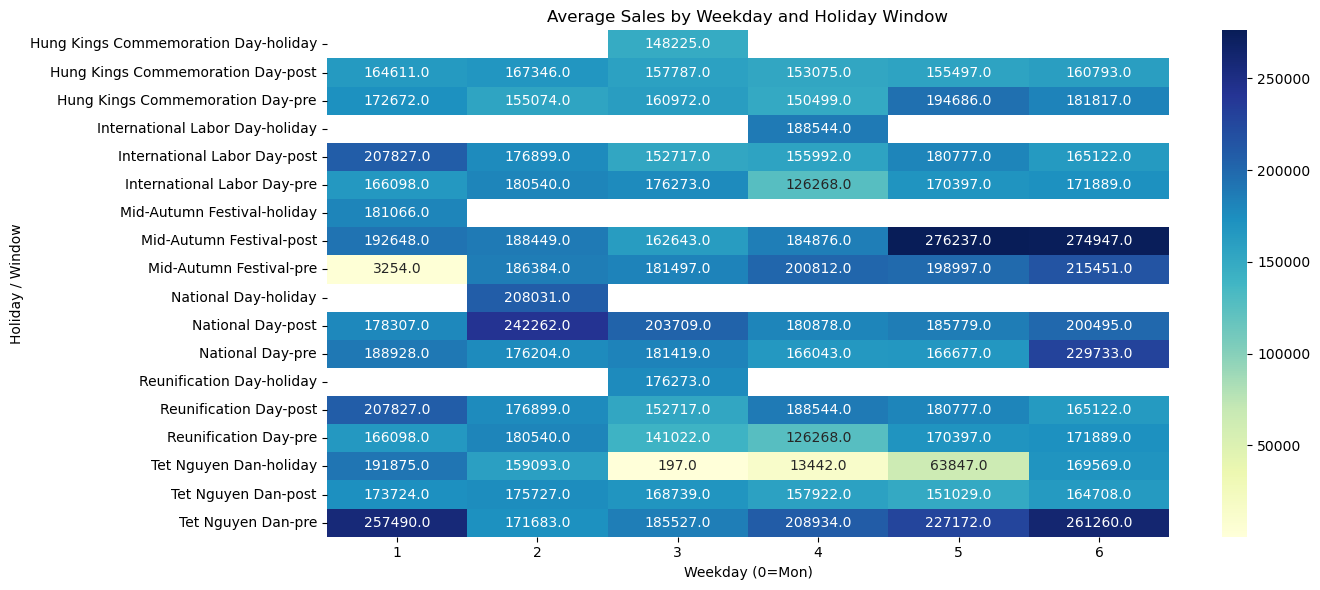

In [19]:
# Prepare heatmap data for weekday vs holiday-window sales
heatmap_data = []
for hw in holiday_windows:
    for window in ["pre", "holiday", "post"]:
        w = hw[window]
        window_sales = daily_sales.filter((pl.col("date") >= pl.lit(w[0])) & (pl.col("date") <= pl.lit(w[1])))
        window_sales = window_sales.with_columns([
            pl.col("date").dt.weekday().alias("weekday")
        ])
        for wd in range(7):
            avg = window_sales.filter(pl.col("weekday") == wd)["daily_quantity"].mean()
            heatmap_data.append({
                "holiday": hw["name"],
                "window": window,
                "weekday": wd,
                "avg_sales": avg
            })
import pandas as pd
heatmap_df = pd.DataFrame(heatmap_data)
# Pivot for heatmap
pivot = heatmap_df.pivot_table(index=["holiday", "window"], columns="weekday", values="avg_sales")
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average Sales by Weekday and Holiday Window")
plt.ylabel("Holiday / Window")
plt.xlabel("Weekday (0=Mon)")
plt.tight_layout()
plt.show()

## 10. Decision Rule: Evaluate Holiday Effect

Summarize statistical results and visualizations. Decide whether the holiday effect is strong and consistent enough to justify further feature development or recommendation strategies.

## Data-Driven Summary: Holiday Effect Analysis Results

Based on the computed sales lift and statistical tests for each major Vietnamese holiday in 2025:

- **Tet Nguyen Dan**: Sales during the holiday were *lower* than the baseline (lift = -32.7%). The t-test p-value (0.137) indicates this decrease is not statistically significant at the 0.05 level.
- **Hung Kings Commemoration Day**: Sales were nearly unchanged (lift = -0.96%), with a very high p-value (0.93), showing no significant effect.
- **Reunification Day**: Sales were *slightly higher* than baseline (lift = +10.3%), but the p-value (0.40) shows this is not statistically significant.
- **International Labor Day**: Sales were *moderately higher* (lift = +18.3%), but the p-value (0.13) is above the significance threshold.
- **National Day**: Sales were *higher* (lift = +21.0%), but again, the p-value (0.13) is not significant.
- **Mid-Autumn Festival**: Sales were essentially unchanged (lift = -2.5%), with a p-value of 1.0 (no effect).

**Conclusion:**
- None of the tested holidays produced a statistically significant change in sales compared to the baseline (all p-values > 0.05).
- The largest observed effect was a decrease during Tet Nguyen Dan, but this was not significant.
- National Day and International Labor Day showed the highest positive lifts, but these were also not significant.
- For this dataset and year, Vietnamese holidays do not have a strong or statistically reliable effect on overall sales volume.

**Recommendation:**
- No special holiday-based demand adjustment or recommendation logic is justified based on these results. Continue monitoring in future years or with more granular data (e.g., by category or region) for possible effects.